# Exercise 2 — ML Key Challenges


In this exercise, you will train several models and observe three cases:

1. Underfitting — model too simple
2. Good fit — model captures the pattern
3. Overfitting — model memorizes the noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


Create synthetic nonlinear data

In [5]:
np.random.seed(42)

X = np.linspace(0, 10, 80).reshape(-1, 1)

y_true = np.sin(X).ravel()

y = y_true + np.random.normal(0, 0.25, size=y_true.shape)


Train / test split

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# For smooth plotting
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

In [7]:
models = [
    {"degree": 1, "name": "Model A"},
    {"degree": 4, "name": "Model B"},
    {"degree": 15, "name": "Model C"},
]

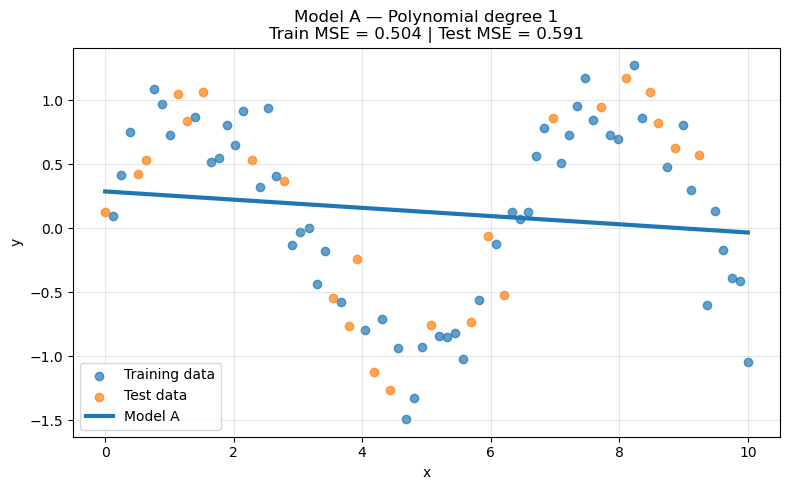

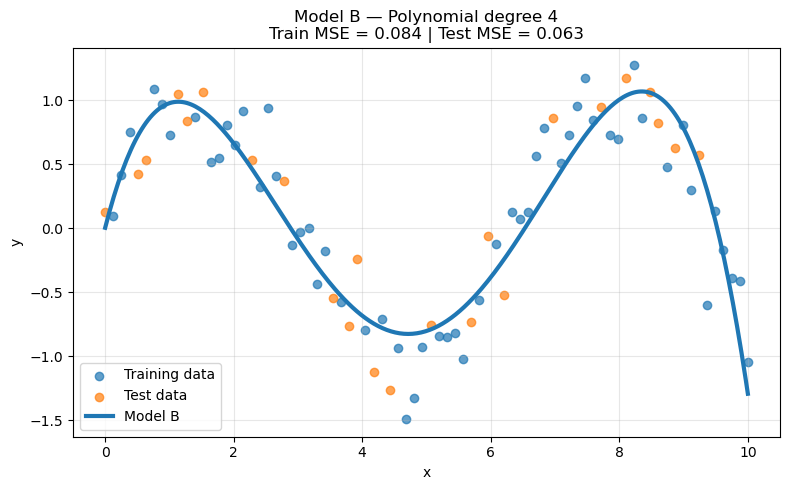

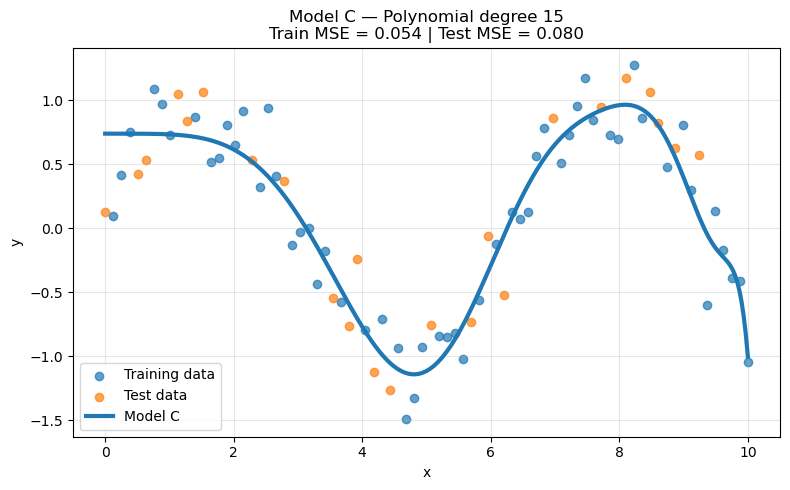

In [8]:
for item in models:
    degree = item["degree"]

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot = model.predict(x_plot)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    plt.figure(figsize=(8, 5))

    plt.scatter(X_train, y_train, alpha=0.7, label="Training data")
    plt.scatter(X_test, y_test, alpha=0.7, label="Test data")
    plt.plot(x_plot, y_plot, linewidth=3, label=item["name"])

    plt.title(
        f"{item['name']} — Polynomial degree {degree}\n"
        f"Train MSE = {train_mse:.3f} | Test MSE = {test_mse:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Questions

1. Which model is underfitting?
2. Which model is overfitting?
3. Which model generalizes best?
4. How do you know from the plot?
5. How do you know from the train/test MSE?

Model A is underfitting

Model C is overfitting

Model B generalizes the best

* Underfitting (Model A): The model is a straight line and completely fails to capture the obvious underlying curved pattern of the data. It is too simple.

* Overfitting (Model C): The curve is highly complex and wiggles excessively to pass as close as possible to the individual training points. By doing so, it captures the random noise in the training set rather than the true underlying trend, leading to poor performance where data points are sparse.

* Generalizing best (Model B): The curve smoothly follows the overall shape of the data points without erratic fluctuations, capturing the true trend well for both the blue (training) and orange (testing) points.

* Underfitting: Model A has high Mean Squared Error (MSE) for both the training set ($0.504$) and the test set ($0.591$). It performs poorly across the board.
* Overfitting: Model C has the lowest Training MSE ($0.054$), meaning it learned the training data exceptionally well. However, its Test MSE ($0.080$) is higher than Model 
B's, indicating that its complex shape does not perform as well on unseen data.    
* Generalizing best: Model B has a low Training MSE ($0.084$) and the lowest overall Test MSE ($0.063$). Because it achieves the lowest error on the unseen test data, it is the best at generalizing.